Solicitação:

O Head de Dados pediu para que você construísse uma tabela contendo  as seguintes informações:

a. País de origem (Brasil).

b. País de destino.

c. Quantidade em litros de vinho exportado (utilize: 1KG =1L). d. Valor em US$.

## Bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

## Dados

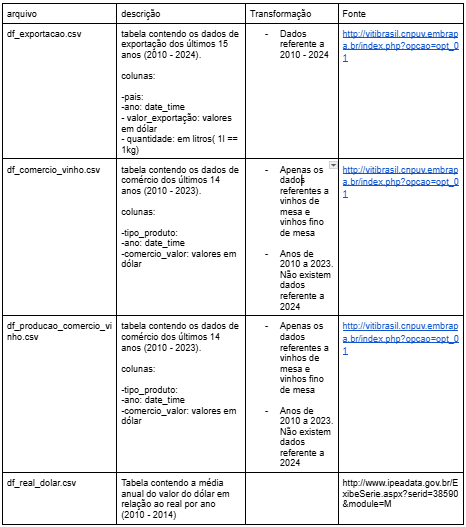

**fontes**

http://www.ipeadata.gov.br/ExibeSerie.aspx?serid=38590&module=M

http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01

In [3]:
url_comercio_producao_vinho = 'https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Bernardo/df_producao_comercio_vinho.csv'
url_exportacao_vinho = 'https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Bernardo/df_exportacao.csv'
url_exportacao_total_vinho = 'https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Bernardo/df_exportacao_total.csv'
url_real_dolar = 'https://raw.githubusercontent.com/fiapostechfase1/tech-challenge/refs/heads/Bernardo/df_real_dolar.csv'


In [4]:
df_comercio_producao_vinho = pd.read_csv(url_comercio_producao_vinho, sep = ',')
df_exportacao_vinho = pd.read_csv(url_exportacao_vinho, sep = ',')
df_exportacao_total_vinho = pd.read_csv(url_exportacao_total_vinho, sep = ',')
df_real_dolar = pd.read_csv(url_real_dolar, sep = ',')


In [5]:
## Dados básicos das bases

## Dados básicos das bases

### Base Exportação

In [6]:
pais_exportacao = df_exportacao_vinho.pais.unique()
ano_exportacao = df_exportacao_vinho.ano.unique()
shape_exportacao = df_exportacao_vinho.shape
colunas_exportacao = df_exportacao_vinho.columns
print(f'''
Colunas na base de exportação:\n\n{colunas_exportacao}\n
Países na base de exportação:\n\n{pais_exportacao}\n
Anos na base de exportação:\n\n{ano_exportacao}\n
Tamanho da base de exportação: {shape_exportacao}
      ''')


Colunas na base de exportação:

Index(['pais', 'ano', 'valor_exportacao', 'quantidade'], dtype='object')

Países na base de exportação:

['Afeganistão' 'Alemanha' 'Angola' 'Anguilla' 'Antilhas Holandesas'
 'Antígua e Barbuda' 'Argentina' 'Argélia' 'Aruba' 'Arábia Saudita'
 'Austrália' 'Bahamas' 'Bangladesh' 'Barbados' 'Barein' 'Belice' 'Benin'
 'Bermudas' 'Bolívia' 'Brasil' 'Bulgária' 'Bélgica' 'Bósnia-Herzegovina'
 'Cabo Verde' 'Camarões' 'Canadá' 'Catar' 'Cayman, Ilhas' 'Chile' 'China'
 'Chipre' 'Cingapura' 'Cocos (Keeling), Ilhas' 'Colômbia' 'Comores'
 'Congo' 'Coreia, Republica Sul' 'Costa Rica' 'Costa do Marfim'
 'Coveite (Kuweit)' 'Croácia' 'Cuba' 'Curaçao' 'Dinamarca' 'Dominica'
 'El Salvador' 'Emirados Arabes Unidos' 'Equador' 'Eslovaca, Republica'
 'Espanha' 'Estados Unidos' 'Estônia' 'Filipinas' 'Finlândia' 'França'
 'Gabão' 'Gana' 'Gibraltar' 'Granada' 'Grécia' 'Guatemala' 'Guiana'
 'Guiana Francesa' 'Guine Bissau' 'Guine Equatorial' 'Haiti' 'Honduras'
 'Hong Kong' 'Hungria

### Base Comércio e Produção

In [7]:
produtos_comercio_producao = df_comercio_producao_vinho.tipo_produto.unique()
ano_comercio_producao = df_comercio_producao_vinho.ano.unique()
shape_comercio_producao = df_comercio_producao_vinho.shape
colunas_comercio_producao = df_comercio_producao_vinho.columns
print(f'''
Colunas na base de comércio e produção:\n\n{colunas_comercio_producao}\n
Produtos na base de comércio e produção:\n\n{produtos_comercio_producao}\n
Anos na base de comércio  e produção:\n\n{ano_comercio_producao}\n
Tamanho da base de comercio e produção: {shape_comercio_producao}
      ''')



Colunas na base de comércio e produção:

Index(['tipo_produto', 'ano', 'producao', 'comercio_valor'], dtype='object')

Produtos na base de comércio e produção:

['vinho_fino_mesa_branco' 'vinho_fino_mesa_rosado' 'vinho_fino_mesa_tinto'
 'vinho_mesa_branco' 'vinho_mesa_rosado' 'vinho_mesa_tinto']

Anos na base de comércio  e produção:

[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]

Tamanho da base de comercio e produção: (84, 4) 
      


## Análises

## Valor por litro

In [8]:
df_exportacao_total_vinho.columns


Index(['ano', 'valor', 'litro', 'valor_litro'], dtype='object')

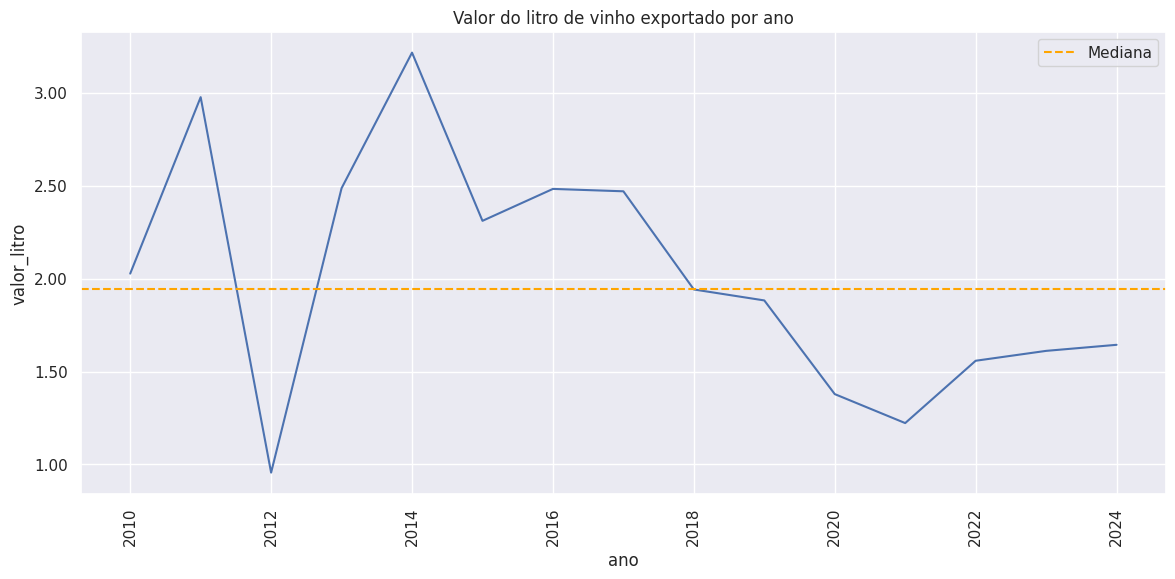

In [9]:
mediana_valor_litro = df_exportacao_total_vinho.valor_litro.median()

sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_exportacao_total_vinho, x='ano', y="valor_litro", legend=False)
plt.title('Valor do litro de vinho exportado por ano')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)

plt.axhline(y=mediana_valor_litro, color='orange', linestyle='--', label='Mediana')

plt.legend()
plt.show()

<ipython-input-10-cd5488d9c286>:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=axes[0], data=df_exportacao_total_vinho, x='ano', y='litro', palette=paleta, legend=False)
<ipython-input-10-cd5488d9c286>:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=axes[1], data=df_exportacao_total_vinho, x='ano', y='valor', palette=paleta, legend=False)
<ipython-input-10-cd5488d9c286>:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=axes[2], data=df_real_dolar, x='ano', y='media_valor_dolar', palette=paleta, legend=False)
<ipython-input-10-cd5488d9c286>:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=axes[3], data=df_exportacao_total_vinho, x='ano', y='valor_litro', palette=paleta, legend=False)


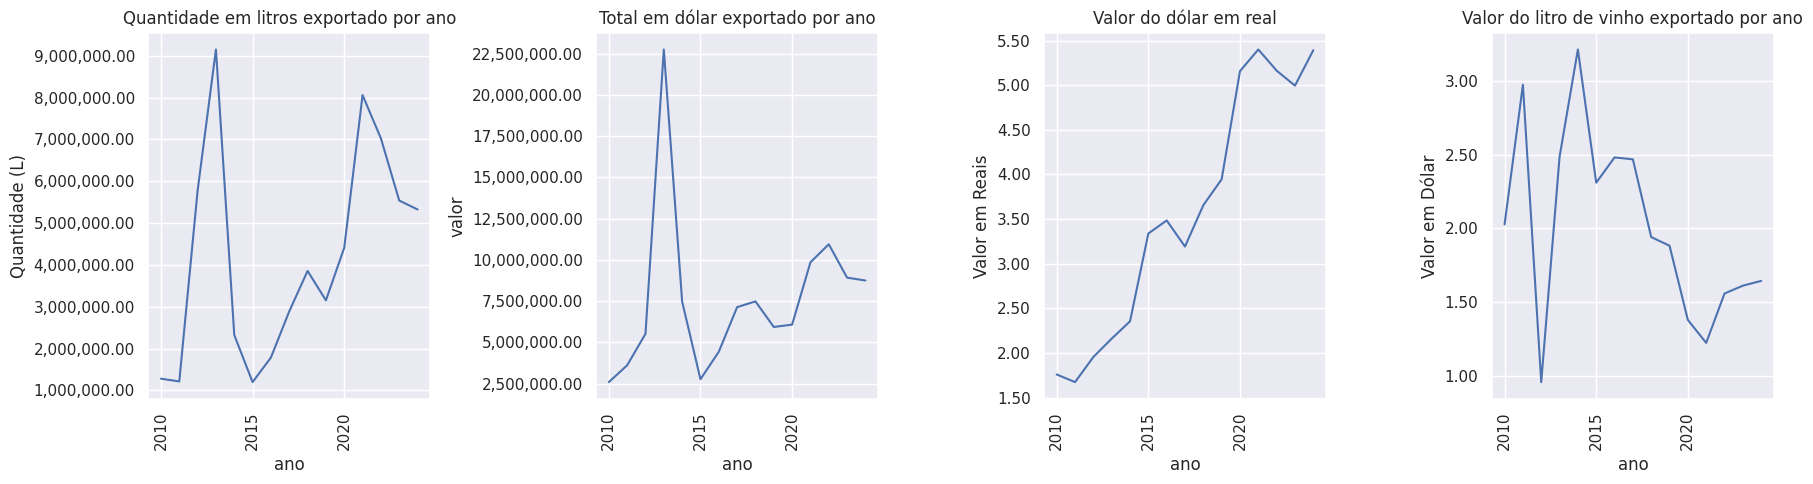

In [10]:
# Define a figura e os eixos
fig, axes = plt.subplots(1, 4, figsize=(18, 5))  # 1 linha, 3 colunas
paleta = sns.color_palette("colorblind", 14)

# Gráfico 1 - Quantidade em litros exportado por ano
sns.lineplot(ax=axes[0], data=df_exportacao_total_vinho, x='ano', y='litro', palette=paleta, legend=False)
axes[0].set_ylabel('Quantidade (L)')
axes[0].set_title('Quantidade em litros exportado por ano')
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[0].tick_params(axis='x', rotation=90)

# Gráfico 2 - Valor total exportado em dólar
sns.lineplot(ax=axes[1], data=df_exportacao_total_vinho, x='ano', y='valor', palette=paleta, legend=False)
axes[1].set_title('Total em dólar exportado por ano')
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[1].tick_params(axis='x', rotation=90)

# Gráfico 3 - Valor do dólar em real
sns.lineplot(ax=axes[2], data=df_real_dolar, x='ano', y='media_valor_dolar', palette=paleta, legend=False)
axes[2].set_title('Valor do dólar em real')
axes[2].set_ylabel('Valor em Reais')
axes[2].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[2].tick_params(axis='x', rotation=90)

# Gráfico 4 - Valor do litro de vinho exportado por ano
sns.lineplot(ax=axes[3], data=df_exportacao_total_vinho, x='ano', y='valor_litro', palette=paleta, legend=False)
axes[3].set_title('Valor do litro de vinho exportado por ano')
axes[3].set_ylabel('Valor em Dólar')
axes[3].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[3].tick_params(axis='x', rotation=90)


# Ajusta o layout e exibe os gráficos
plt.tight_layout()
plt.show()


Análise:

- Vemos uma baixa expressiva no valor do vinho em 2012, seguido por uma alta em 2014. Obs: Necessário entender melhor os dados relacionados a 2012. A quantidade em litros produzida em 2012.

- Em geral podemos perceber que o total em dolar exportado sobe conforme a produção cresce o que podemos esperar.

- A variação do valor do litro teve uma tendência de queda após 2015 com a alta do dólar.

Próximo passo: Necessário cruzar esse dado , com a base de produção para entender se estamos percentualmente exportanto mais ou menos no período. E se o fato da desvalorizaçào afetou positivamente ou negativamente a exportação.



## Análise Países

In [11]:
lista_2024 = ['Paraguai','Haiti', 'Estados Unidos', 'Guiana', 'Venezuela']

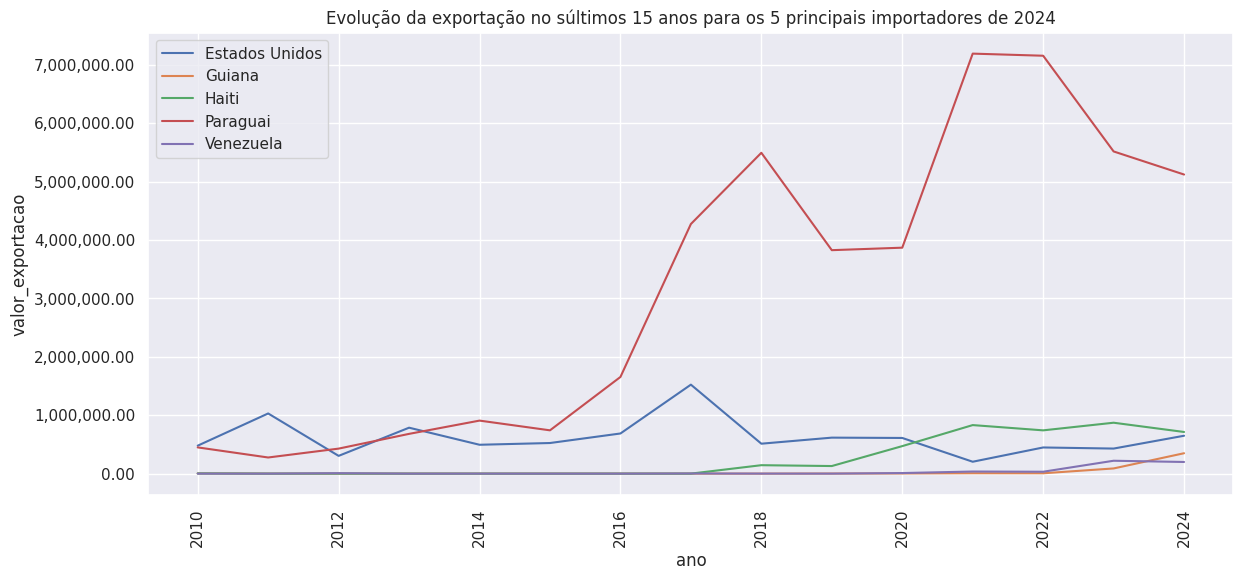

In [12]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_exportacao_vinho.query("pais in @lista_2024"), x="ano", y="valor_exportacao", hue="pais")
plt.title('Evolução da exportação no súltimos 15 anos para os 5 principais importadores de 2024')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [13]:
#lista com os maiores importadores dos ultimos 15 anos
exportacao_agrupado = df_exportacao_vinho.groupby(['pais'])['valor_exportacao'].sum().reset_index()
exportacao_agrupado_ordenado = exportacao_agrupado.sort_values(by='valor_exportacao', ascending=False)

In [14]:
#lista maiores importadores
lista_5_maiores_importadores = exportacao_agrupado_ordenado.pais[:5]

In [15]:
#lista maiores importadores
lista_6_10_maiores_importadores = exportacao_agrupado_ordenado.pais[6:11]

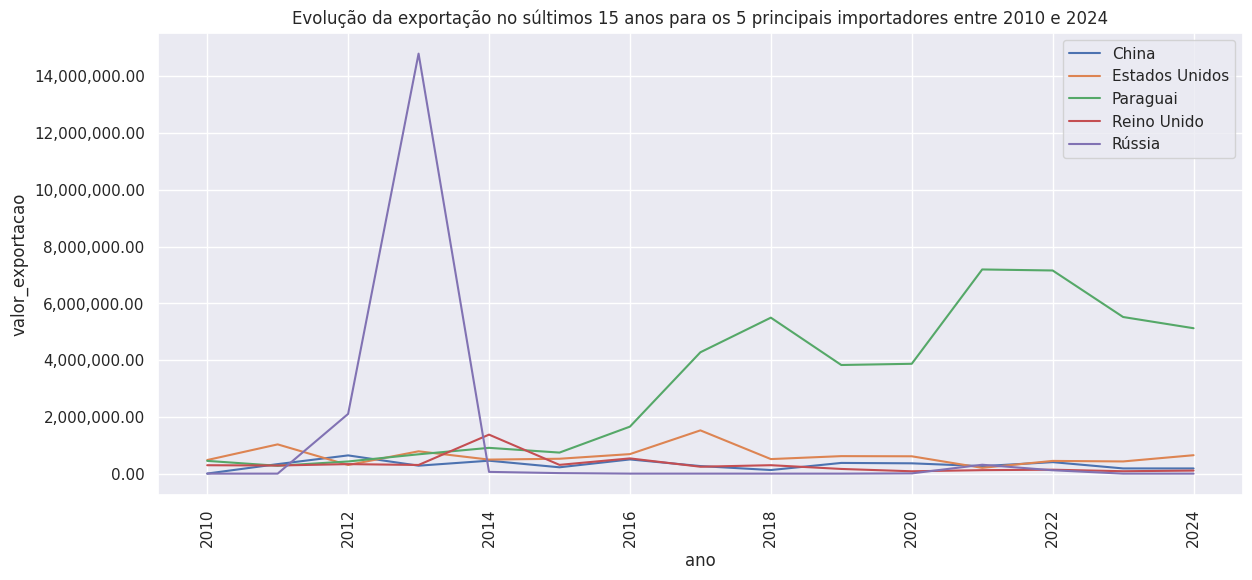

In [16]:
lista_maiores_exportadores = exportacao_agrupado_ordenado.pais[:6]
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_exportacao_vinho.query("pais in @lista_5_maiores_importadores"), x="ano", y="valor_exportacao", hue="pais")
plt.title('Evolução da exportação no súltimos 15 anos para os 5 principais importadores entre 2010 e 2024')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.legend()
plt.show()

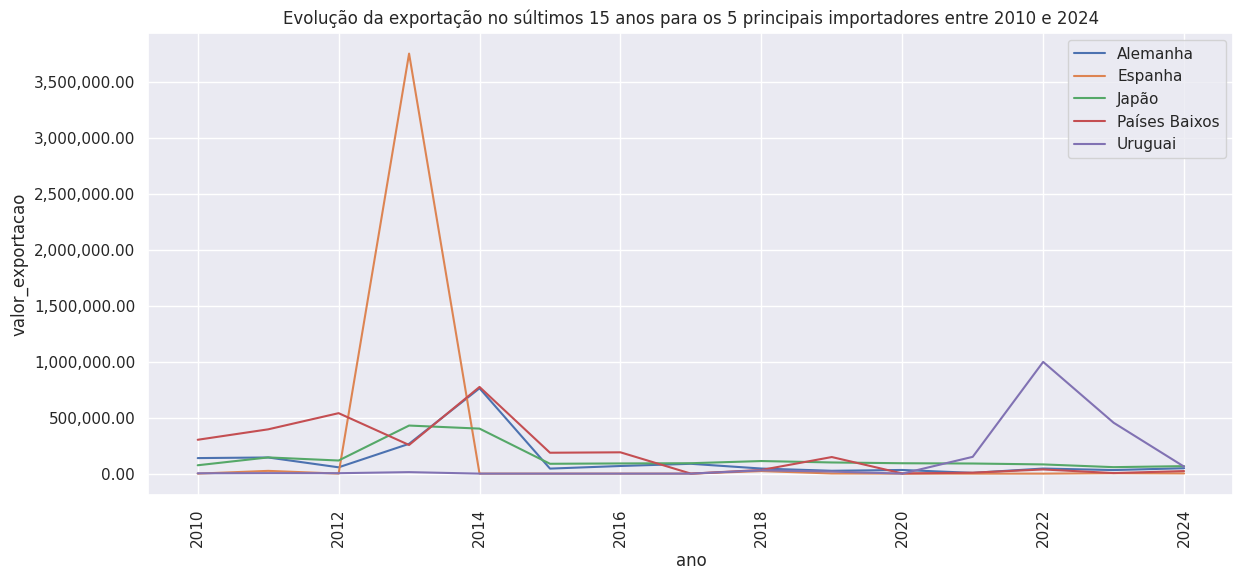

In [17]:
lista_maiores_exportadores = exportacao_agrupado_ordenado.pais[:6]
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_exportacao_vinho.query("pais in @lista_6_10_maiores_importadores"), x="ano", y="valor_exportacao", hue="pais")
plt.title('Evolução da exportação no súltimos 15 anos para os 5 principais importadores entre 2010 e 2024')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.legend()
plt.show()

<ipython-input-20-d96c7049c993>:7: UserWarning: The palette list has more values (14) than needed (5), which may not be intended.
  sns.lineplot(ax=axes[0], data=df1, x="ano", y="valor_exportacao", hue="pais", palette=paleta)
<ipython-input-20-d96c7049c993>:15: UserWarning: The palette list has more values (14) than needed (5), which may not be intended.
  sns.lineplot(ax=axes[1], data=df2, x="ano", y="valor_exportacao", hue="pais", palette=paleta)


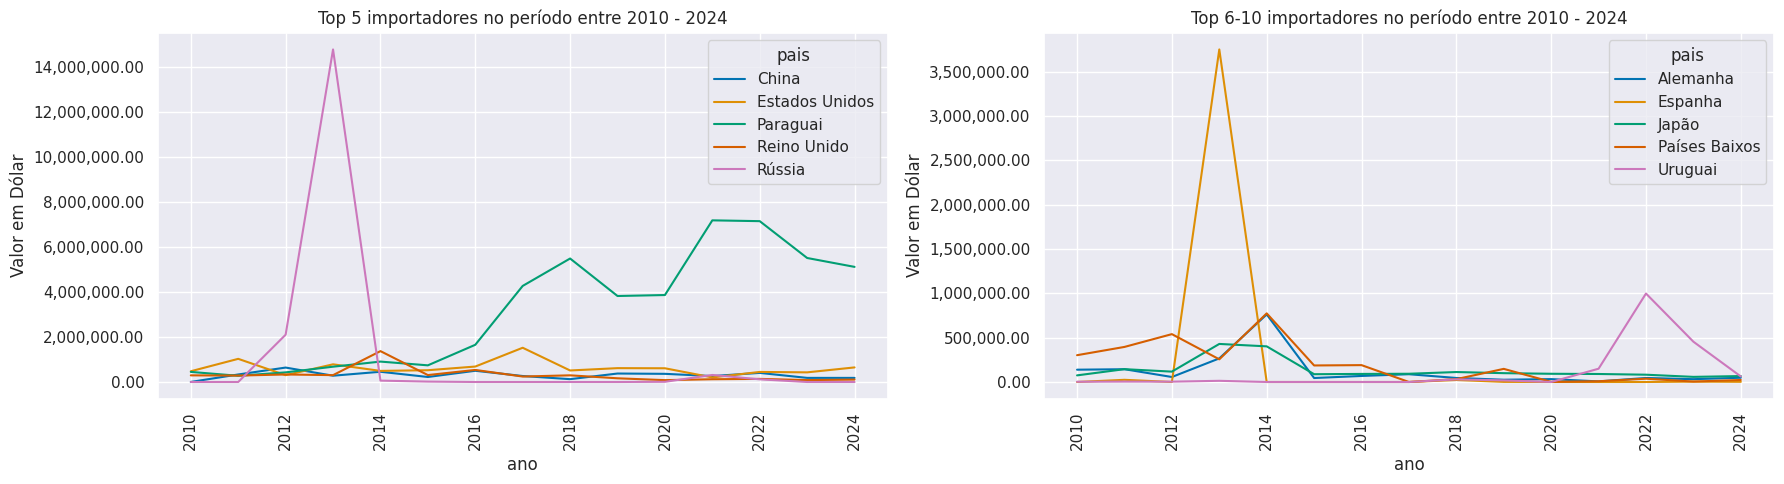

In [20]:
# Define a figura e os eixos
fig, axes = plt.subplots(1, 2, figsize=(18, 5))  # 1 linha, 2 colunas
paleta = sns.color_palette("colorblind", 14)

# Gráfico 1 – Top 5 importadores
df1 = df_exportacao_vinho.query("pais in @lista_5_maiores_importadores")
sns.lineplot(ax=axes[0], data=df1, x="ano", y="valor_exportacao", hue="pais", palette=paleta)
axes[0].set_ylabel('Valor em Dólar')
axes[0].set_title('Top 5 importadores no período entre 2010 - 2024')
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[0].tick_params(axis='x', rotation=90)

# Gráfico 2 – Top 6-10 importadores
df2 = df_exportacao_vinho.query("pais in @lista_6_10_maiores_importadores")
sns.lineplot(ax=axes[1], data=df2, x="ano", y="valor_exportacao", hue="pais", palette=paleta)
axes[1].set_ylabel('Valor em Dólar')
axes[1].set_title('Top 6-10 importadores no período entre 2010 - 2024')
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[1].tick_params(axis='x', rotation=90)

# Ajusta o layout e exibe os gráficos
plt.tight_layout()
plt.show()

<ipython-input-23-824be2eed0b2>:7: UserWarning: The palette list has more values (14) than needed (5), which may not be intended.
  sns.lineplot(ax=axes[0], data=df1, x="ano", y="quantidade", hue="pais", palette=paleta)
<ipython-input-23-824be2eed0b2>:15: UserWarning: The palette list has more values (14) than needed (5), which may not be intended.
  sns.lineplot(ax=axes[1], data=df2, x="ano", y="quantidade", hue="pais", palette=paleta)


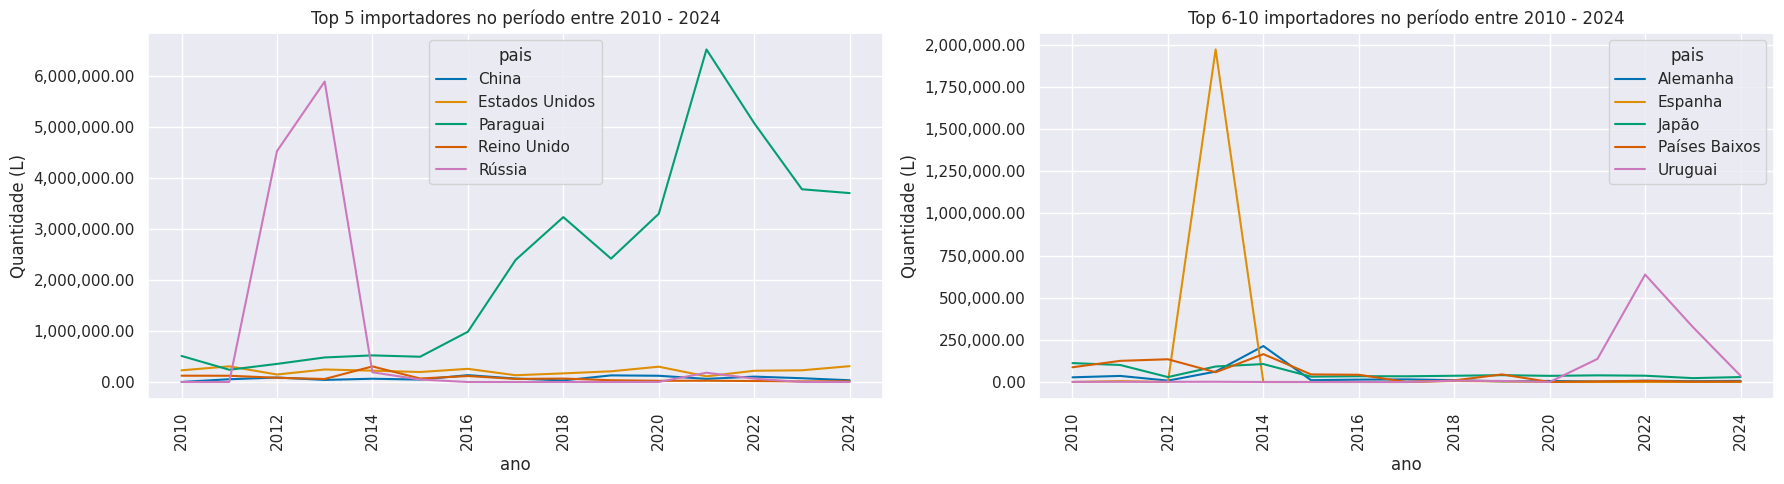

In [23]:
# Define a figura e os eixos
fig, axes = plt.subplots(1, 2, figsize=(18, 5))  # 1 linha, 2 colunas
paleta = sns.color_palette("colorblind", 14)

# Gráfico 1 – Top 5 importadores
df1 = df_exportacao_vinho.query("pais in @lista_5_maiores_importadores")
sns.lineplot(ax=axes[0], data=df1, x="ano", y="quantidade", hue="pais", palette=paleta)
axes[0].set_ylabel('Quantidade (L)')
axes[0].set_title('Top 5 importadores no período entre 2010 - 2024')
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[0].tick_params(axis='x', rotation=90)

# Gráfico 2 – Top 6-10 importadores
df2 = df_exportacao_vinho.query("pais in @lista_6_10_maiores_importadores")
sns.lineplot(ax=axes[1], data=df2, x="ano", y="quantidade", hue="pais", palette=paleta)
axes[1].set_ylabel('Quantidade (L)')
axes[1].set_title('Top 6-10 importadores no período entre 2010 - 2024')
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
axes[1].tick_params(axis='x', rotation=90)

# Ajusta o layout e exibe os gráficos
plt.tight_layout()
plt.show()

Análise:

Países como Rússia, Espanha e Uruguai realizaram compras fora do padrão de comportamento em anos específicos. Necessário entender se isso se dá por conta de algum fator específico relacionado a safra daquele ano.

Outros países como estados unidos, Reino Unido mantém um padrão no valor de importação ao longo dos anos.

O destaque mesmo vem do Paraguai que a partir de 2016 elevou o valor de importação do vinho brasileiro, inclusive sendo responsável pelo aumento da exportação do produto no país.

## Análise de comercialização por tipo de Vinhos

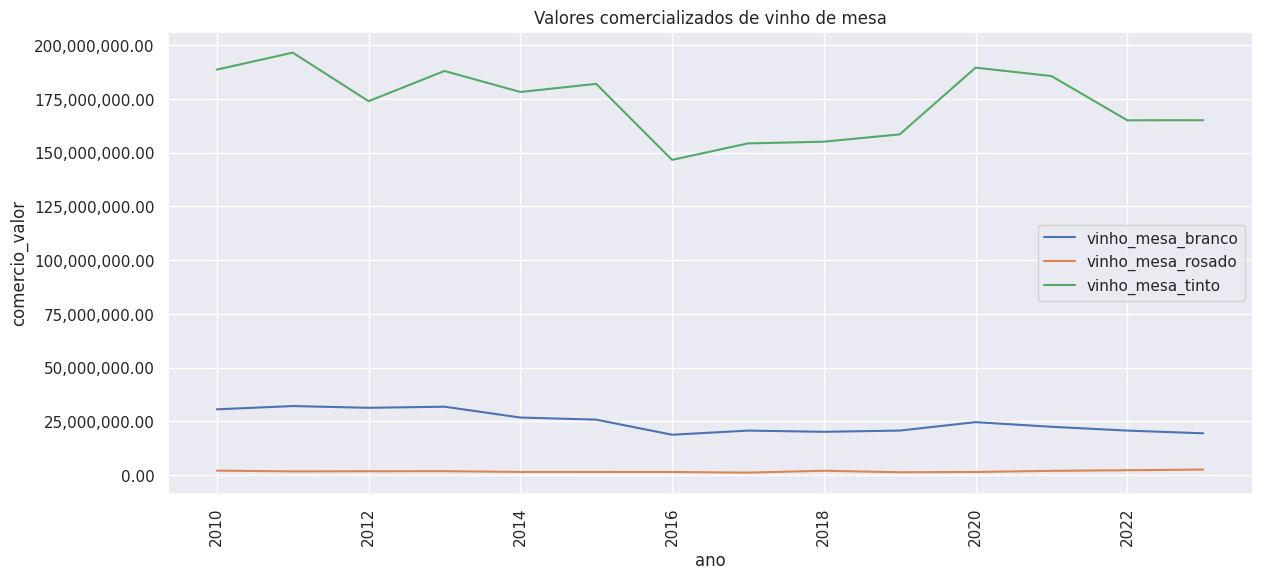

In [28]:
vinho_mesa = ['vinho_mesa_branco', 'vinho_mesa_rosado', 'vinho_mesa_tinto']
lista_maiores_exportadores = exportacao_agrupado_ordenado.pais[:6]
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_comercio_producao_vinho.query("tipo_produto in @vinho_mesa"), x="ano", y="comercio_valor", hue="tipo_produto")
plt.title('Valores comercializados de vinho de mesa')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.legend()
plt.show()

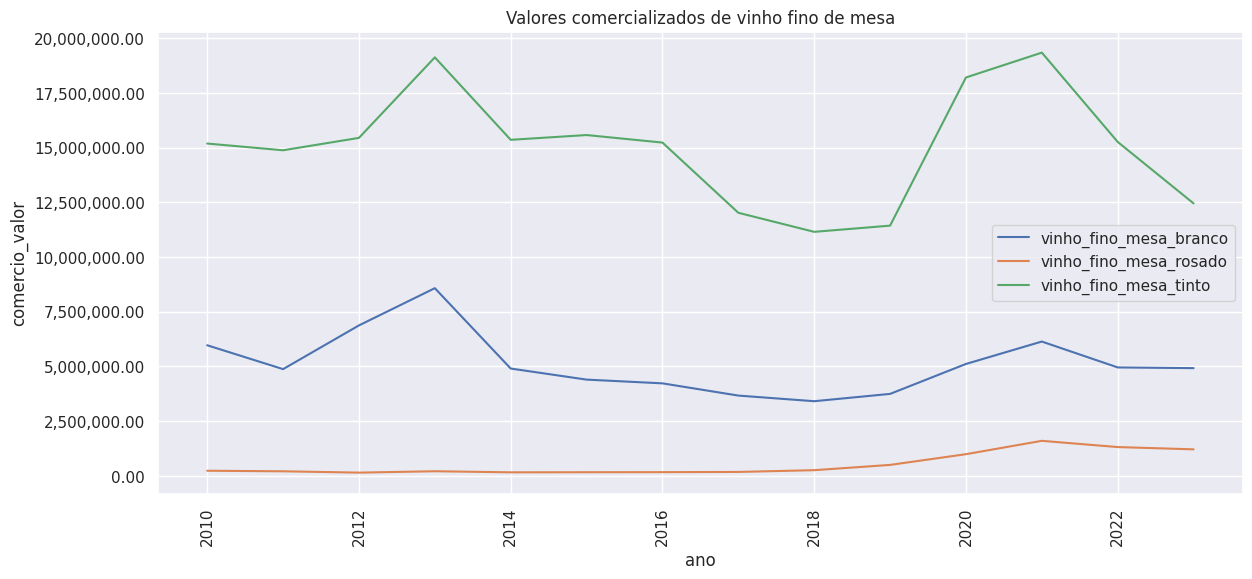

In [29]:
vinho_mesa = ['vinho_fino_mesa_branco', 'vinho_fino_mesa_rosado', 'vinho_fino_mesa_tinto']
lista_maiores_exportadores = exportacao_agrupado_ordenado.pais[:6]
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_comercio_producao_vinho.query("tipo_produto in @vinho_mesa"), x="ano", y="comercio_valor", hue="tipo_produto")
plt.title('Valores comercializados de vinho fino de mesa')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Análise de Produção por tipo de vinhos

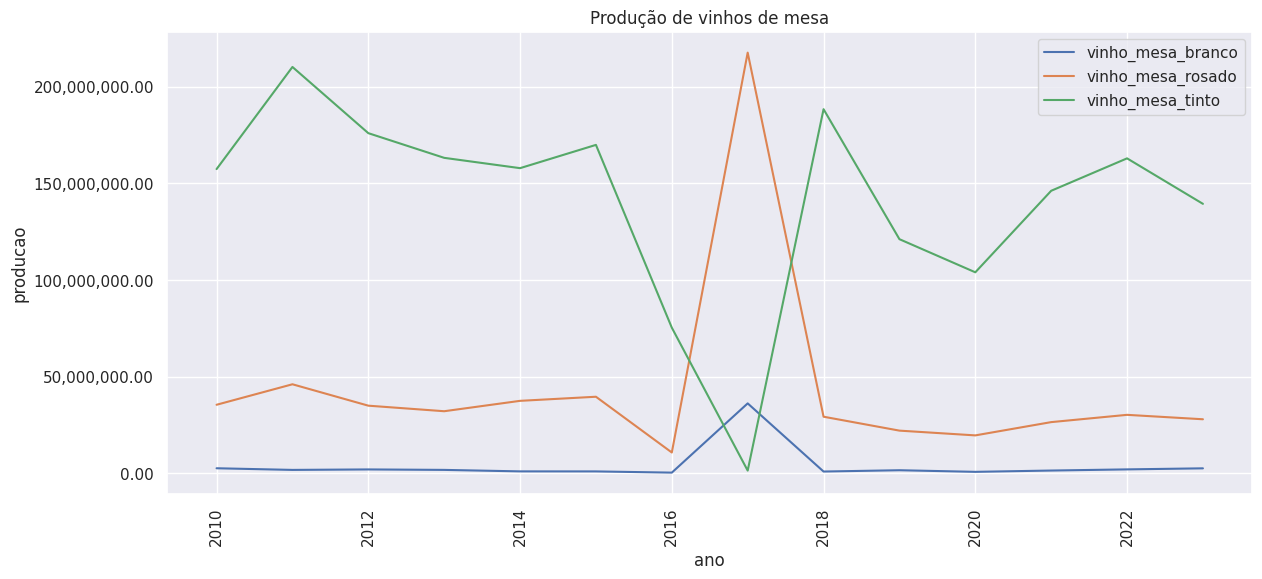

In [33]:
vinho_mesa = ['vinho_mesa_branco', 'vinho_mesa_rosado', 'vinho_mesa_tinto']
lista_maiores_exportadores = exportacao_agrupado_ordenado.pais[:6]
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_comercio_producao_vinho.query("tipo_produto in @vinho_mesa"), x="ano", y="producao", hue="tipo_produto")
plt.title('Produção de vinhos de mesa')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.legend()
plt.show()

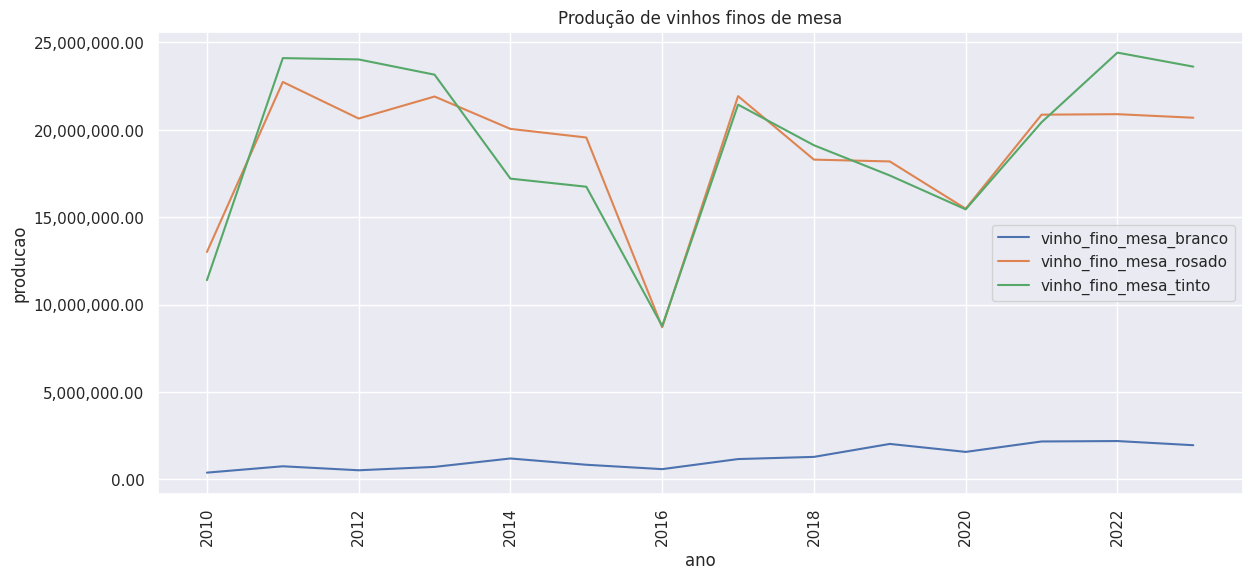

In [34]:
vinho_mesa = ['vinho_fino_mesa_branco', 'vinho_fino_mesa_rosado', 'vinho_fino_mesa_tinto']
lista_maiores_exportadores = exportacao_agrupado_ordenado.pais[:6]
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_comercio_producao_vinho.query("tipo_produto in @vinho_mesa"), x="ano", y="producao", hue="tipo_produto")
plt.title('Produção de vinhos finos de mesa')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.legend()
plt.show()